# Multivariate polynomial-emulation diagnostics

For either the Legendre or Chebyshev probability measure, the tensor-product
basis is

$$
\Psi_\nu(x)=\prod_{j=1}^d\psi_{\nu_j}(x_j).
$$

This notebook compares total-degree sets
$\{\nu:|\nu|_1\leq p\}$ and lower hyperbolic crosses
$\{\nu:\prod_j(\nu_j+1)\leq n+1\}$ for all three multiplier activations.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neural_polynomial_emulation import (
    emulated_multivariate_basis,
    exact_multivariate_basis,
    hyperbolic_cross_indices,
    total_degree_indices,
)

DIMENSION = 2
ORDER = 4
NUM_POINTS = 1024
RELU_LAYERS = 12
TANH_TOLERANCE = 1e-4
FAMILIES = ("legendre", "chebyshev")
PRODUCTS = ("relu", "tanh", "repu2")

if DIMENSION < 1:
    raise ValueError("DIMENSION must be positive")
if ORDER < 0:
    raise ValueError("ORDER must be nonnegative")


## Multi-index sets


In [2]:
index_sets = {
    "total_degree": total_degree_indices(DIMENSION, ORDER),
    "hyperbolic_cross": hyperbolic_cross_indices(DIMENSION, ORDER),
}

pd.DataFrame(
    [
        {
            "index_set": name,
            "dimension": DIMENSION,
            "order": ORDER,
            "cardinality": len(indices),
            "max_univariate_degree": int(np.max(indices)),
        }
        for name, indices in index_sets.items()
    ]
)


,index_set,dimension,order,cardinality,max_univariate_degree
0,total_degree,2,4,15,4
1,hyperbolic_cross,2,4,10,4


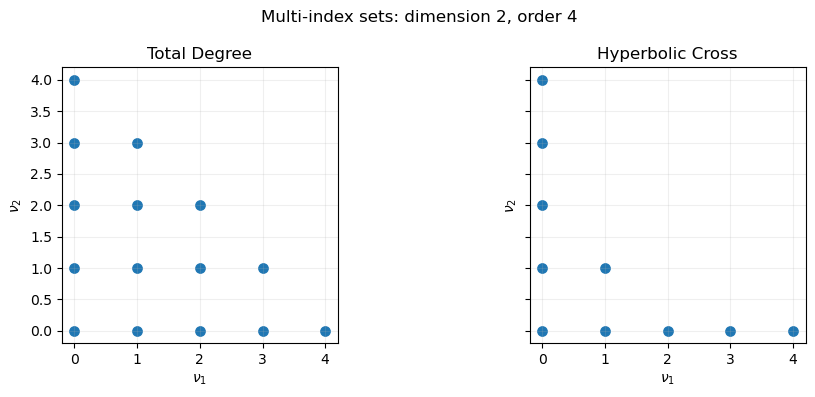

In [3]:
if DIMENSION == 2:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    for ax, (name, indices) in zip(axes, index_sets.items()):
        ax.scatter(indices[:, 0], indices[:, 1], s=45)
        ax.set(
            xlabel=r"$\nu_1$",
            ylabel=r"$\nu_2$",
            title=name.replace("_", " ").title(),
        )
        ax.set_aspect("equal")
        ax.grid(alpha=0.2)
    fig.suptitle(f"Multi-index sets: dimension {DIMENSION}, order {ORDER}")
    fig.tight_layout()
    plt.show()


## Exact-versus-emulated basis matrices

The same point cloud is used for both families because the reported metric is
the pointwise basis error. Probability-measure orthonormality is tested
separately in the package test suite.


In [4]:
rng = np.random.default_rng(24680)
points = rng.uniform(-0.95, 0.95, size=(NUM_POINTS, DIMENSION))
rows = []

for family in FAMILIES:
    for index_set_name, indices in index_sets.items():
        exact = exact_multivariate_basis(points, indices, family=family)
        for product in PRODUCTS:
            approximate = emulated_multivariate_basis(
                points,
                indices,
                family=family,
                product=product,
                num_layers=RELU_LAYERS,
                tanh_tolerance=TANH_TOLERANCE,
            ).numpy()
            errors = np.max(np.abs(approximate - exact), axis=0)
            rows.extend(
                {
                    "family": family,
                    "index_set": index_set_name,
                    "product": product,
                    "feature": feature,
                    "multi_index": tuple(indices[feature]),
                    "sample_max_error": error,
                }
                for feature, error in enumerate(errors)
            )

error_table = pd.DataFrame(rows)
error_table.groupby(["family", "index_set", "product"])["sample_max_error"].agg(
    ["max", "median"]
)


max        median
family    index_set        product                            
chebyshev hyperbolic_cross relu     8.584002e-05  6.904833e-07
                           repu2    6.744605e-15  1.110223e-15
                           tanh     4.097202e-05  6.066148e-07
          total_degree     relu     8.584002e-05  1.036162e-06
                           repu2    6.744605e-15  1.554312e-15
                           tanh     6.648816e-05  8.176344e-07
legendre  hyperbolic_cross relu     1.105040e-04  9.363102e-07
                           repu2    1.176836e-14  1.221245e-15
                           tanh     6.145803e-05  1.091832e-06
          total_degree     relu     1.105040e-04  1.975883e-06
                           repu2    1.176836e-14  2.220446e-15
                           tanh     6.145803e-05  2.695127e-06

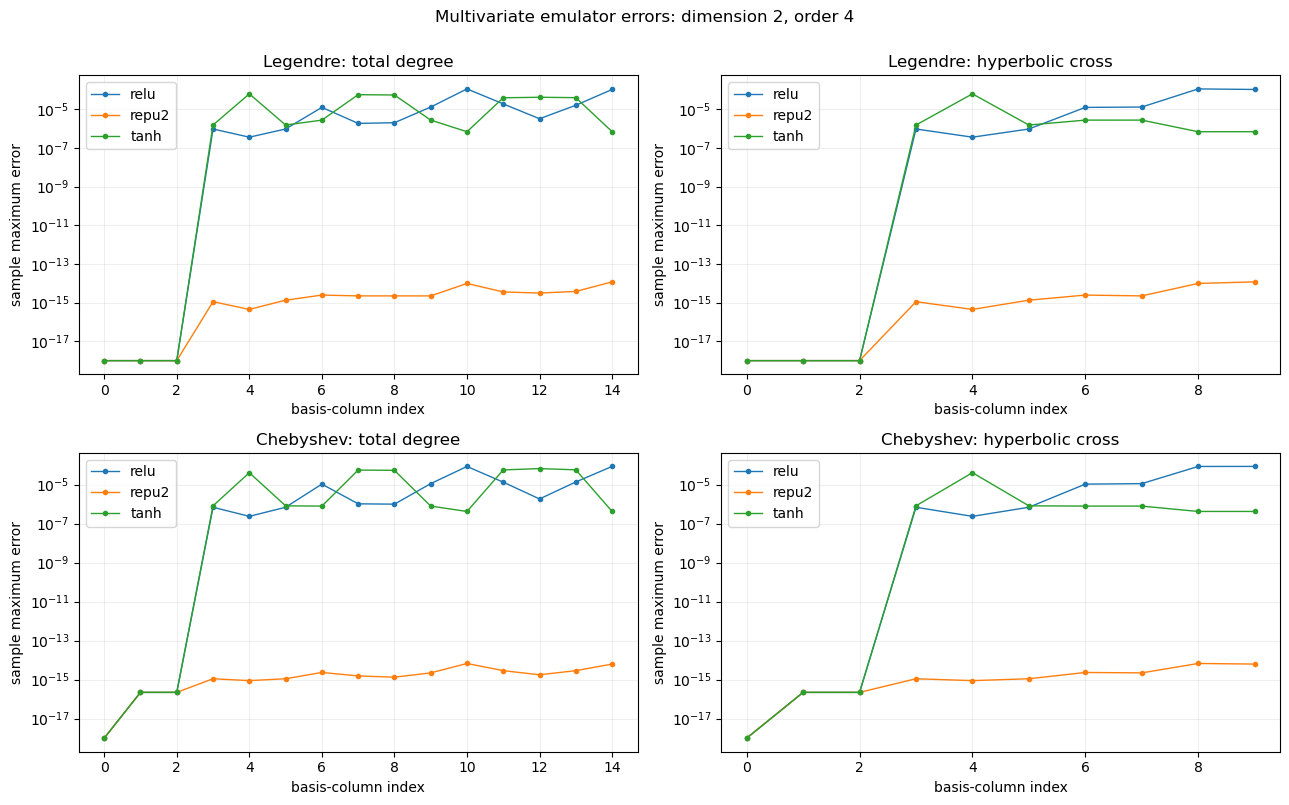

In [5]:
fig, axes = plt.subplots(
    len(FAMILIES), len(index_sets), figsize=(13, 8), squeeze=False
)
for row, family in enumerate(FAMILIES):
    for column, index_set_name in enumerate(index_sets):
        ax = axes[row, column]
        subset = error_table[
            (error_table["family"] == family)
            & (error_table["index_set"] == index_set_name)
        ]
        for product, group in subset.groupby("product"):
            ax.semilogy(
                group["feature"],
                np.maximum(group["sample_max_error"], 1e-18),
                marker="o",
                markersize=3,
                linewidth=1,
                label=product,
            )
        ax.set(
            xlabel="basis-column index",
            ylabel="sample maximum error",
            title=f"{family.title()}: {index_set_name.replace('_', ' ')}",
        )
        ax.grid(alpha=0.2)
        ax.legend()
fig.suptitle(
    f"Multivariate emulator errors: dimension {DIMENSION}, order {ORDER}",
    y=1.0,
)
fig.tight_layout()
plt.show()
